# Projet 6 : Détection de faux billets 

Dans la zone euro, on compte 17 faux billets en circulation pour 1 million d'authentiques, ratio en baisse constante chaque année. Parmi les outils de lutte contre le faux monnayage, le machine learning peut permettre de détecter ces fraudes, en s'appuyant sur des caractères quantitatifs comme les mesures des billets. 

Nous créerons ici un algorithme de détection des fausses billets, en partant d'un jeu de données contenant les caractéristiques géométriques de vraies et fausses coupures. La tâche consistera à limiter au maximum le nombre de faux billets prédits comme vrais.

On s'appuiera sur un clustering de type k-means pour vérifier la linéarité de nos données. Après cette confirmation, on pourra créer un classifieur de type régression logistique, modèle qu'on convertira en fonction autonome de détection.


In [1]:
#import des librairies Python
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.formula.api as smf 
import sklearn as sk 
from sklearn import preprocessing 

In [2]:
sns.set(style='white', context='notebook', # Styles de Seaborn
        palette=['#ff5252', '#1de9b6'])

def save_fig(file_name): # Fonction d'export des graphiques
    return plt.savefig('/Users/tahirihoussain/Desktop/_AAAAOPENCLASSROOMS/PROJET 6 /HOUSSAIN_TAHIRI_P6/'+ file_name, dpi=150, bbox_inches='tight')

### Chargement des données sources : 

In [3]:
data=pd.read_csv('/Users/tahirihoussain/Desktop/_AAAAOPENCLASSROOMS/PROJET 6 /HOUSSAIN_TAHIRI_P6/notes.csv', sep=",", decimal=".", header=0)
data 

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.67,103.74,103.70,4.01,2.87,113.29
2,True,171.83,103.76,103.76,4.40,2.88,113.84
3,True,171.80,103.78,103.65,3.73,3.12,113.63
4,True,172.05,103.70,103.75,5.04,2.27,113.55
...,...,...,...,...,...,...,...
165,False,172.11,104.23,104.45,5.24,3.58,111.78
166,False,173.01,104.59,104.31,5.04,3.05,110.91
167,False,172.47,104.27,104.10,4.88,3.33,110.68
168,False,171.82,103.97,103.88,4.73,3.55,111.87


### Lexique : 

Le fichier notes.csv liste les caractéristiques de 170 billets de banque différents. On dispose de l'authenticité de 
chaque billet (True ou False), et de 6 mesures toutes exprimées en millimètres

Le dataframe contient les caractéristiques géométriques de billets de banque.
Pour chacun d'eux, nous connaissons :

        - length : la longueur du billet (en mm) ;

        - height_left : la hauteur du billet *(mesurée sur le côté gauche, en mm);

        - height_right : La hauteur du billet (mesurée sur le côté droit, en mm) ;

        - margin_up : la marge entre le bord supérieur du billet et l'image de celui-ci (en mm) ;

        - margin_low : la marge entre le bord inférieur du billet et l'image de celui-ci (en mm) ;

        - diagonal : la diagonale du billet (en mm) ;

        - is_genuine : Indication si le billet est vrai (True) ou faux (False). 
        

### Analyse du dataframe : 

In [4]:
data.head() 

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.67,103.74,103.70,4.01,2.87,113.29
2,True,171.83,103.76,103.76,4.40,2.88,113.84
3,True,171.80,103.78,103.65,3.73,3.12,113.63
4,True,172.05,103.70,103.75,5.04,2.27,113.55


In [5]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    170 non-null    bool   
 1   diagonal      170 non-null    float64
 2   height_left   170 non-null    float64
 3   height_right  170 non-null    float64
 4   margin_low    170 non-null    float64
 5   margin_up     170 non-null    float64
 6   length        170 non-null    float64
dtypes: bool(1), float64(6)
memory usage: 8.3 KB


In [6]:
 # Aucun doublon 
print(len(data) - len(data.drop_duplicates()), 'doublon')

0 doublon


In [7]:
data.describe() 

,diagonal,height_left,height_right,margin_low,margin_up,length
count,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000
mean,171.940588,104.066353,103.928118,4.612118,3.170412,112.570412
std,0.305768,0.298185,0.330980,0.702103,0.236361,0.924448
min,171.040000,103.230000,103.140000,3.540000,2.270000,109.970000
25%,171.730000,103.842500,103.690000,4.050000,3.012500,111.855000
50%,171.945000,104.055000,103.950000,4.450000,3.170000,112.845000
75%,172.137500,104.287500,104.170000,5.127500,3.330000,113.287500
max,173.010000,104.860000,104.950000,6.280000,3.680000,113.980000


In [8]:
data['is_genuine'].value_counts() 

True     100
False     70
Name: is_genuine, dtype: int64

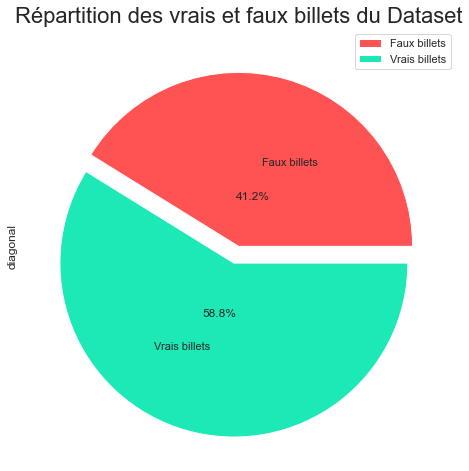

In [9]:
data_genuine = data.groupby("is_genuine").count()
data_genuine.plot.pie(y="diagonal",figsize=(8, 8),
                                explode = [0, 0.1],
                                labels = ["Faux billets", "Vrais billets"],
                                autopct = '%1.1f%%',
                                pctdistance = 0.3, labeldistance = 0.5)

plt.title('Répartition des vrais et faux billets du Dataset', 
  loc='center', 
  fontsize=22) 
save_fig('Répartition des vrais et faux billets')
plt.show() 

#### Synthèse des observations sur le dataframe : 

> Nous disposons de données sur 170 billets. 

>> Dont 41,2% sont faux, ce qui fait 70 billets.

>> Dont 58,8% de billets sont des vrais billets, ce qui fait 100 vrais billets.   

> Dans notre datadrame nous n'avons pas de doublons. 

> Nous ne décelons pas d'outliers dans les données du dataframe. 

> L'ensemble des mesures et renseigné dans le data frame, nous n'avons pas de valeur nulls. Les 170 individus ont l'ensemble de leurs variables complétées 

> Nous ne décelons pas de valeurs abérantes. 
is_genuine ne compte bien que 2 valeurs par exemple. 
Les moyennes, minimum et maximum semblent cohérent ainsi que les écart-types. 

## Analyse des corrélations : 

### Corrélation entres les variables par deux :  

  - La fonction (sns.pairplot) trace l'histogramme de chaque variable quantitative, pour chaque classe de la               variable catégorielle is_genuine.

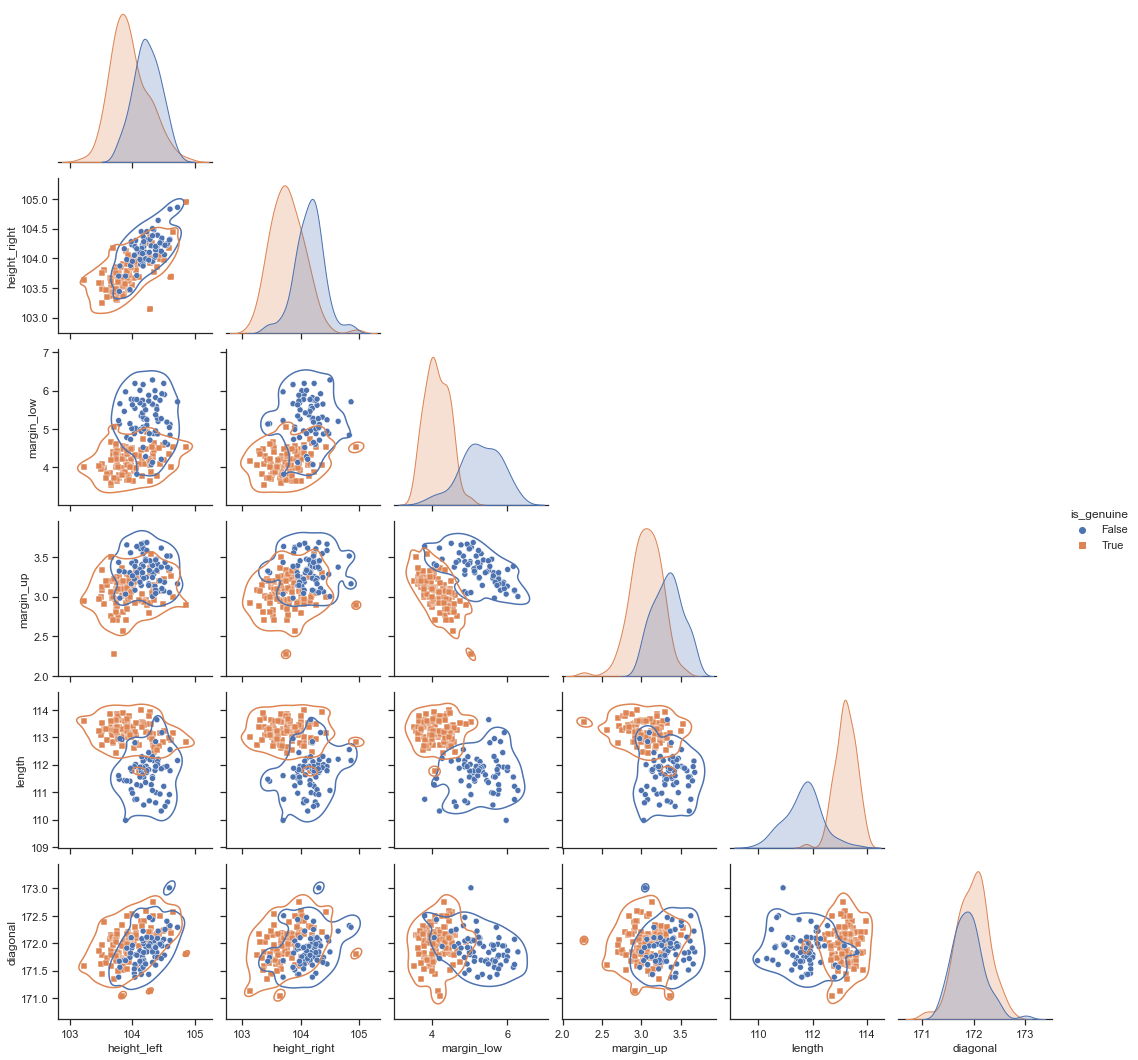

In [10]:
# Pairplot sur les variables 2 à 2 du dataset
sns.set(style="ticks")
g = sns.pairplot(data[["height_left","height_right","margin_low","margin_up","length","diagonal","is_genuine"]], hue="is_genuine",markers=['o','s'], corner=True)
g.map_lower(sns.kdeplot, levels=2, color='.2')
save_fig('pairplot')
plt.show() 


> On constate que le graphique qui croise 'margin_low'(abscisse) et length(ordonnée) permet de mieux distinguer le vrai billet et les faux billets. La longueur et la marge basse permettent de mieux de discriminer les vrais billets des faux. Les faux billets sont plus courts que les vrais, et leur marge basse est à l'inverse nettement plus longue.

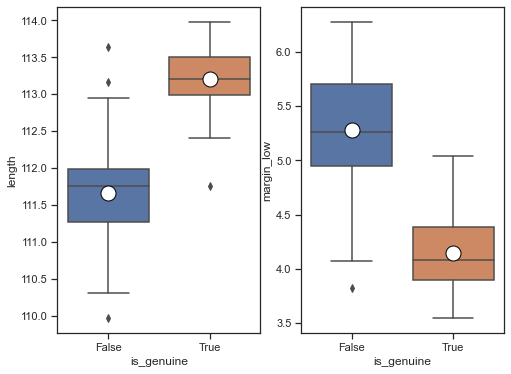

In [11]:
#boxplot sur les variables 'length' et 'margin low'
fig, ax = plt.subplots(1,2, figsize=(8,6))
meanprops = {"marker":"o","markerfacecolor":"white", "markeredgecolor":"black", "markersize":"15"}
sns.boxplot(data=data, y='length', x='is_genuine', showmeans=True, meanprops=meanprops, ax=ax[0])
sns.boxplot(data=data, y='margin_low', x='is_genuine', showmeans=True, meanprops=meanprops, ax=ax[1])
save_fig('boxplots')
plt.show() 

In [12]:
# la matrice des corrélation sur data. 
matrix = data.corr()
matrix 

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
is_genuine,1.000000,0.139223,-0.461730,-0.551309,-0.800111,-0.582801,0.825743
diagonal,0.139223,1.000000,0.319584,0.220418,-0.181020,-0.027366,0.080295
height_left,-0.461730,0.319584,1.000000,0.734390,0.424530,0.324788,-0.421387
height_right,-0.551309,0.220418,0.734390,1.000000,0.509375,0.366918,-0.417021
margin_low,-0.800111,-0.181020,0.424530,0.509375,1.000000,0.171113,-0.637352
margin_up,-0.582801,-0.027366,0.324788,0.366918,0.171113,1.000000,-0.525284
length,0.825743,0.080295,-0.421387,-0.417021,-0.637352,-0.525284,1.000000


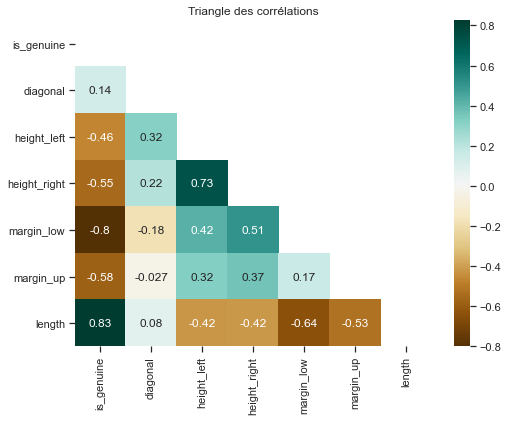

In [13]:
#heatmap sur data 
mask = np.triu(np.ones_like(matrix, dtype=np.bool))
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, mask=mask, annot=True, cmap='BrBG')
plt.title('Triangle des corrélations')
save_fig('triangle-correlations')
plt.show() 

#### synthèse de l'analyse des corrélations : 

> La matrice des corrélation et le heatmap confirment l'impact de la longueur et de la marge basse sur l'authenticité (plus de 0.8 d'écart à 0). 

> Nous concluons que la véracité du billet est corrélée positivement à la longueur, et négativement à la marge basse. 

> Les variables ont toutes des dépendances plus ou moins marquées avec les autres, à part dans une moindre mesure la diagonale. 

> commentaire sur les boxplots : Nous pouvons voir à travers les boxplots que la longueur des faux billets est plus courte que celle des vrais et inversement pour la marge basse, nous voyons qu'elle est plus longue pour les faux billets.  


# Réalisation de l'ACP : 

### Standardisation des variables : 

In [14]:
data.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.67,103.74,103.70,4.01,2.87,113.29
2,True,171.83,103.76,103.76,4.40,2.88,113.84
3,True,171.80,103.78,103.65,3.73,3.12,113.63
4,True,172.05,103.70,103.75,5.04,2.27,113.55


In [15]:
data.describe() 

,diagonal,height_left,height_right,margin_low,margin_up,length
count,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000
mean,171.940588,104.066353,103.928118,4.612118,3.170412,112.570412
std,0.305768,0.298185,0.330980,0.702103,0.236361,0.924448
min,171.040000,103.230000,103.140000,3.540000,2.270000,109.970000
25%,171.730000,103.842500,103.690000,4.050000,3.012500,111.855000
50%,171.945000,104.055000,103.950000,4.450000,3.170000,112.845000
75%,172.137500,104.287500,104.170000,5.127500,3.330000,113.287500
max,173.010000,104.860000,104.950000,6.280000,3.680000,113.980000


> Tous nos variables sont exprimées en millimètres, certes c'est des observations exprimées dans la même unité de mesure, mais elles n'ont pas la même échelle de grandeur. 

> Si nous regardons dans les min et les max dans les valeurs de nos variable, on voit que pour les ('height_left','height_right','length') sont de la même grandeur : dans les  110mn. alors que la variable 'length'dépassent les 170mn, sans parler des variables ('margin_low' et 'margin_up') qui tournent autour de 4mn. 

>Si nous procédons à une analyse ACP sur nos données 'telquel', nous risquons de voir un résultat trop dominé par le poids des variables 'diagonal' et 'height_left','height_right','length') aux dépends des variables ('margin_low' et 'margin_up'). 

> Nous procèderons donc, à une standardisatin de nos variables pour éviter tout risque de sur-représentation d'une variable par rapport aux autres. Nous transformerons nos données pour que tous nos variables auront une moyenne de 0 et un ecart type de 1. 

In [16]:
# Préparation des données pour l'ACP 
#standardisation des variables 

# Variables quantitatives à standardiser
X = data.drop(['is_genuine'], axis=1) 

# Fit des valeurs sur le modèle
std_scale = sk.preprocessing.StandardScaler().fit(X) 

# Valeurs standardisées
X_std = pd.DataFrame(std_scale.transform(X), columns=X.columns) 
X_std

,diagonal,height_left,height_right,margin_low,margin_up,length
0,-0.428344,2.669454,3.096563,-0.131590,-1.189874,0.281633
1,-0.887559,-1.097697,-0.691254,-0.860126,-1.274740,0.780697
2,-0.362742,-1.030427,-0.509439,-0.303010,-1.232307,1.377405
3,-0.461145,-0.963156,-0.842767,-1.260106,-0.213913,1.149571
4,0.358883,-1.232238,-0.539742,0.611230,-3.820725,1.062777
...,...,...,...,...,...,...
165,0.555689,0.550431,1.581436,0.896930,1.738009,-0.857535
166,3.507789,1.761301,1.157201,0.611230,-0.510944,-1.801418
167,1.736529,0.684972,0.520847,0.382670,0.677182,-2.050950
168,-0.395543,-0.324086,-0.145809,0.168395,1.610710,-0.759892


In [17]:
#vérification de la standardisation avec 'describe'
X_std.describe() 

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1.700000e+02,1.700000e+02,1.700000e+02,1.700000e+02,1.700000e+02,1.700000e+02
mean,7.720622e-15,3.147662e-14,3.611662e-14,6.661338e-16,-1.558557e-15,-1.379681e-14
std,1.002954e+00,1.002954e+00,1.002954e+00,1.002954e+00,1.002954e+00,1.002954e+00
min,-2.954029e+00,-2.813096e+00,-2.388197e+00,-1.531521e+00,-3.820725e+00,-2.821245e+00
25%,-6.907527e-01,-7.529355e-01,-7.215570e-01,-8.029855e-01,-6.700684e-01,-7.761662e-01
50%,1.447108e-02,-3.818593e-02,6.630909e-02,-2.315852e-01,-1.747245e-03,2.979069e-01
75%,6.458924e-01,7.438342e-01,7.329650e-01,7.362241e-01,6.771821e-01,7.779851e-01
max,3.507789e+00,2.669454e+00,3.096563e+00,2.382571e+00,2.162340e+00,1.529294e+00


In [18]:
#vérification de la standardisation avec 'describe' 
X_std.describe().round(2) 

,diagonal,height_left,height_right,margin_low,margin_up,length
count,170.00,170.00,170.00,170.00,170.00,170.00
mean,0.00,0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.95,-2.81,-2.39,-1.53,-3.82,-2.82
25%,-0.69,-0.75,-0.72,-0.80,-0.67,-0.78
50%,0.01,-0.04,0.07,-0.23,-0.00,0.30
75%,0.65,0.74,0.73,0.74,0.68,0.78
max,3.51,2.67,3.10,2.38,2.16,1.53


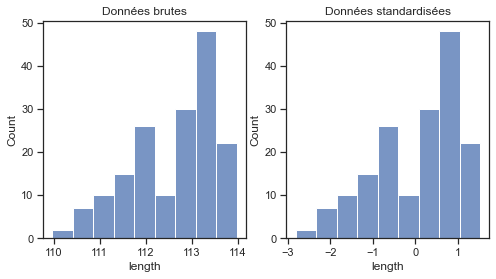

In [19]:
# affichage des données avant et après la standardisation
fig, ax = plt.subplots(1,2, figsize=(8,4))

sns.histplot(data['length'], ax=ax[0])

sns.histplot(X_std['length'], ax=ax[1])

ax[0].title.set_text('Données brutes')
ax[1].title.set_text('Données standardisées')
save_fig('histogramme_std') 
plt.show() 

<AxesSubplot:ylabel='Density'>

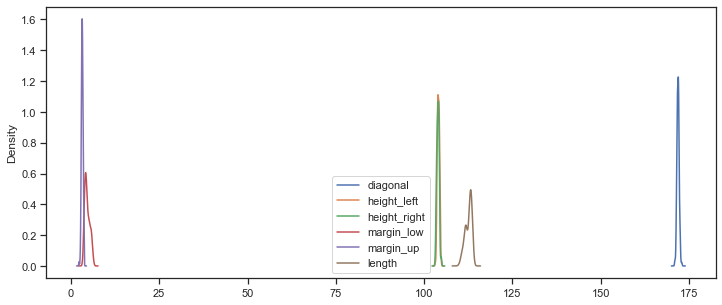

In [20]:
#avant la standardisation
X = pd.DataFrame(X,columns=X.columns) 
X.plot(kind='density',sharex=True,figsize=(12,5),layout=(10,1))

<AxesSubplot:ylabel='Density'>

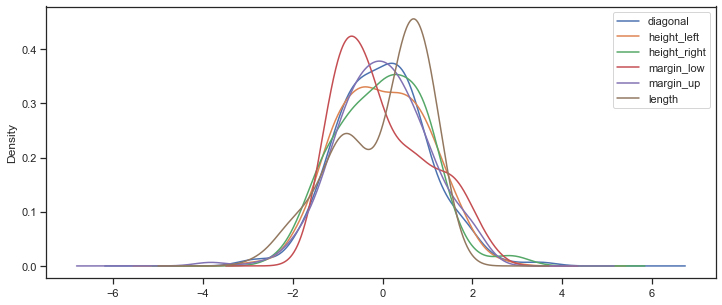

In [21]:
# après la standardisation 
pd.DataFrame(X_std,columns=X.columns).plot(kind='density',sharex=True,figsize=(12,5),layout=(10,1))

> Comme vous pouvez le constater, toutes les distributions sont maintenant centrées autour de la valeur 0 et ont une dispersion similaire. La variation des données est toujours préservée (vous pouvez voir que la forme des lignes du graphique de densité reste similaire à celle du graphique original pour chaque variable).

> L'ACP est sensible à la variance, nous avons standardisés nos variable de sorte que la moyenne de chaque variable soit égale à 0, on soustrait à toutes les observations la moyenne de la variable concernée. 

> Notre résultat est confirmé par describe.  

> Notre résultat est confirmé par l'affichage des donnée avant et après la standardisation. 

> Maintenant que nous avons éliminé le biais causé par les différentes échelles, nous pouvons passer à l'étape suivante.

## Performing PCA : 

In [22]:
# import des librairies 
from sklearn.decomposition import PCA
import matplotlib
import matplotlib.pyplot as plt

#selection du nombre de composante. 6 dimension pour 6 variables
# Create the PCA model
pca = PCA(n_components=6)
num_components = 6 
# Fit the model with the standardised data
pca.fit(X_std) 
  

PCA(n_components=6)

In [23]:
# pourcentage de la variance expliquée pour chaque composante de PC1 à  PC6. 
print(pca.explained_variance_ratio_) 
print(pca.explained_variance_ratio_.round(2)) 

[0.47447921 0.21957106 0.14234524 0.08526295 0.04612822 0.03221331]
[0.47 0.22 0.14 0.09 0.05 0.03]


In [24]:
# la somme cumulative de la variance expliquée des composantes principales. 
print(pca.explained_variance_ratio_.cumsum()) 
print(pca.explained_variance_ratio_.cumsum().round(2)) 

[0.47447921 0.69405027 0.83639551 0.92165846 0.96778669 1.        ]
[0.47 0.69 0.84 0.92 0.97 1.  ]


> Array of the variance of the data explained by each of the 6 principal components, starting with PC1, the principal component that explains most of the variance. 

> Express the explained variance ratio as a cumulative sum

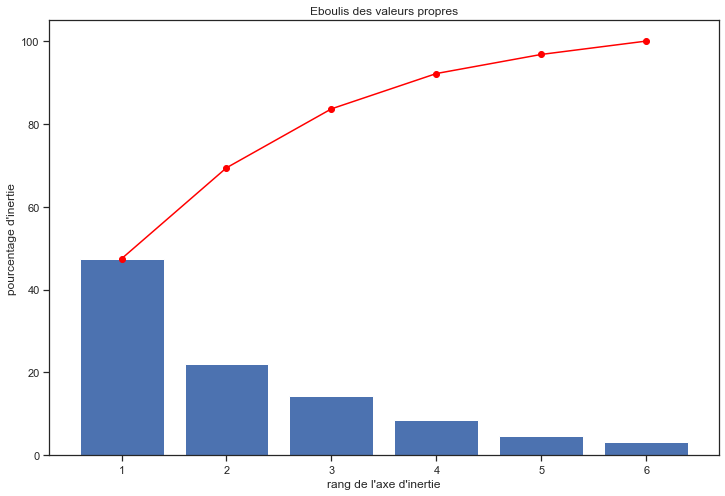

In [25]:
#variance expliquée 
valprop = pca.explained_variance_

#proportion de variance expliquée 
valprop_ratio = pca.explained_variance_ratio_

# Eboulis des valeurs propres
varexpl = valprop_ratio*100
fig = plt.figure(figsize=(12,8))
plt.bar(np.arange(len(varexpl))+1, varexpl)
plt.plot(np.arange(len(varexpl))+1, varexpl.cumsum(),c="red",marker='o')
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres") 
plt.show(block=False) 


> Les barres bleues montrent le pourcentage de variance expliqué par chaque composante principale (ceci provient de pca.explained_variance_ratio_).  La ligne rouge montre la somme cumulative (provenant de pca.explained_variance_ratio_.cumsum()). 

> On remarque ici que les 2 premiers axes cumulent 69.40% de l'inertie totale. Une analyse sur les deux plan factoriels semble donc cohérante. 

> Cependant les trois premiers axes PC1, PC2 et PC3 conservent plus de 80 % des "informations" contenues dans les données. 

#### La question qui s'imposent : 

   > Contenue de notre problèmatique de cassification entre vrai/faux billet, pouvons nous nous contenter de 69,40% variation expliquée. ? 
   
   > Doit on aller chercher à expliquer 80% des variations? 
   

#### Component Scores

In [26]:
from sklearn import decomposition
from sklearn import datasets
from sklearn.preprocessing import scale 
# To get the loadings, we just need to access the attribute components_ of the sklearn.decomposition.pca.PCA object.b
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2','PC3','PC4','PC5','PC6',], index=['diagonal','height_left','height_right','margin_low','margin_up','length'])
loadings


,PC1,PC2,PC3,PC4,PC5,PC6
diagonal,0.073275,0.779639,-0.088894,-0.559732,-0.225094,0.122166
height_left,0.475502,0.339250,0.122760,0.278046,0.715921,0.232131
height_right,0.491821,0.235543,0.153830,0.458938,-0.486993,-0.480813
margin_low,0.431027,-0.320537,0.512808,-0.226528,-0.311908,0.547630
margin_up,0.352540,-0.141120,-0.821149,0.135340,-0.193943,0.354380
length,-0.465373,0.314536,0.126913,0.573703,-0.254417,0.523951


In [27]:
palette = sns.color_palette("bright", 10)
# fonction affichage du cercle des corrélations 
def display_circles(pcs, n_comp, pca, axis_ranks, labels=None, label_rotation=0, lims=None):
    """Display correlation circles, one for each factorial plane"""

    # For each factorial plane
    for d1, d2 in axis_ranks: 
        if d2 < n_comp:

            # Initialise the matplotlib figure
            fig, ax = plt.subplots(figsize=(10,10))

            # Determine the limits of the chart
            if lims is not None :
                xmin, xmax, ymin, ymax = lims
            elif pcs.shape[1] < 30 :
                xmin, xmax, ymin, ymax = -1, 1, -1, 1
            else :
                xmin, xmax, ymin, ymax = min(pcs[d1,:]), max(pcs[d1,:]), min(pcs[d2,:]), max(pcs[d2,:])

            # Add arrows
            # If there are more than 30 arrows, we do not display the triangle at the end
            if pcs.shape[1] < 30 :
                plt.quiver(np.zeros(pcs.shape[1]), np.zeros(pcs.shape[1]),
                   pcs[d1,:], pcs[d2,:], 
                   angles='xy', scale_units='xy', scale=1, color="grey")
                # (see the doc : https://matplotlib.org/api/_as_gen/matplotlib.pyplot.quiver.html)
            else:
                lines = [[[0,0],[x,y]] for x,y in pcs[[d1,d2]].T]
                ax.add_collection(LineCollection(lines, axes=ax, alpha=.1, color='black'))
            
            # Display variable names
            if labels is not None:  
                for i,(x, y) in enumerate(pcs[[d1,d2]].T):
                    if x >= xmin and x <= xmax and y >= ymin and y <= ymax :
                        plt.text(x, y, labels[i], fontsize='14', ha='center', va='center', rotation=label_rotation, color="blue", alpha=0.5)
            
            # Display circle
            circle = plt.Circle((0,0), 1, facecolor='none', edgecolor='b')
            plt.gca().add_artist(circle)

            # Define the limits of the chart
            plt.xlim(xmin, xmax)
            plt.ylim(ymin, ymax)
        
            # Display grid lines
            plt.plot([-1, 1], [0, 0], color='grey', ls='--')
            plt.plot([0, 0], [-1, 1], color='grey', ls='--')

            # Label the axes, with the percentage of variance explained
            plt.xlabel('PC{} ({}%)'.format(d1+1, round(100*pca.explained_variance_ratio_[d1],1)))
            plt.ylabel('PC{} ({}%)'.format(d2+1, round(100*pca.explained_variance_ratio_[d2],1)))

            plt.title("Correlation Circle (PC{} and PC{})".format(d1+1, d2+1))
            plt.show(block=False) 


In [28]:
# fonction d'affichage des observations sur le plan factoriel 
def display_factorial_planes(X_projected, n_comp, pca, axis_ranks, labels=None, alpha=1, illustrative_var=None):
    '''Display a scatter plot on a factorial plane, one for each factorial plane'''
    # For each factorial plane
    for d1,d2 in axis_ranks:
        if d2 < n_comp:
 
            # Initialise the matplotlib figure      
            fig = plt.figure(figsize=(7,6))
        
            # Display the points
            if illustrative_var is None:
                plt.scatter(X_projected[:, d1], X_projected[:, d2], alpha=alpha)
            else:
                illustrative_var = np.array(illustrative_var)
                for value in np.unique(illustrative_var):
                    selected = np.where(illustrative_var == value)
                    plt.scatter(X_projected[selected, d1], X_projected[selected, d2], alpha=alpha, label=value)
                plt.legend()

            # Display the labels on the points
            if labels is not None:
                for i,(x,y) in enumerate(X_projected[:,[d1,d2]]):
                    plt.text(x, y, labels[i],
                              fontsize='14', ha='center',va='center') 
                
            # Define the limits of the chart
            boundary = np.max(np.abs(X_projected[:, [d1,d2]])) * 1.1
            plt.xlim([-boundary,boundary])
            plt.ylim([-boundary,boundary])
        
            # Display grid lines
            plt.plot([-100, 100], [0, 0], color='grey', ls='--')
            plt.plot([0, 0], [-100, 100], color='grey', ls='--')

            # Label the axes, with the percentage of variance explained
            plt.xlabel('PC{} ({}%)'.format(d1+1, round(100*pca.explained_variance_ratio_[d1],1)))
            plt.ylabel('PC{} ({}%)'.format(d2+1, round(100*pca.explained_variance_ratio_[d2],1)))

            plt.title("Projection of points (on PC{} and PC{})".format(d1+1, d2+1))

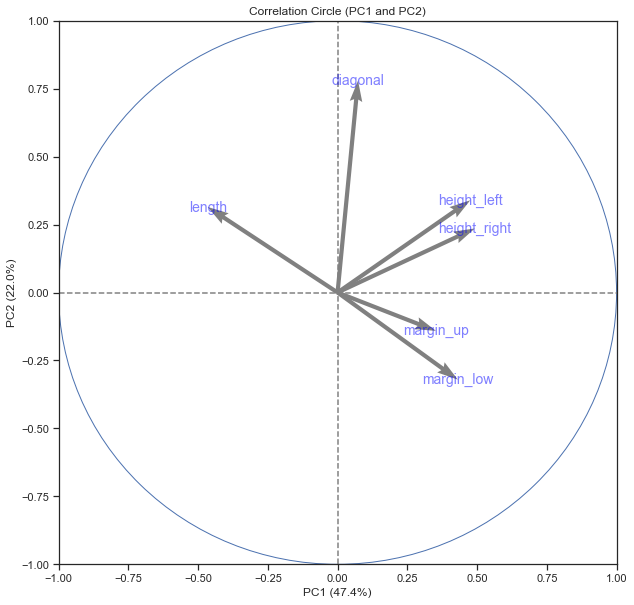

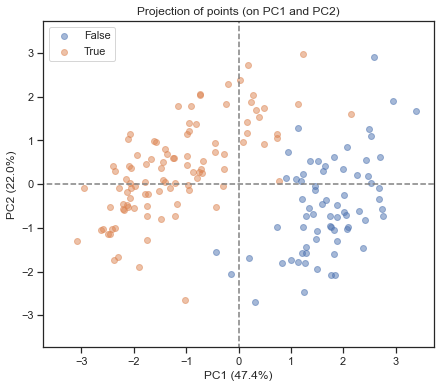

In [29]:
# Generate a correlation circle
pcs = pca.components_ 
n_components = num_components
display_circles(pcs, num_components, pca, [(0,1)], labels = np.array(X.columns),)

# Transform the original scaled data to the new vector space and display data points
Vrai_Faux = [data.loc[uni_id, "is_genuine"] for uni_id in range(0,len(X_std))]
X_projected = pca.transform(X_std) 
display_factorial_planes(X_projected, num_components, pca, [(0,1)], illustrative_var = Vrai_Faux, alpha = 0.5)

Aprés la lecture de cercle de corrélation que nous effectuer ci dessus, les corrélation entre les 6 variables de départ ont bien été conservées après réduction en 2 dimensions.

Nous constatons que les variables "Height_left" et "Height_right" sont bien corrélées positivement avec l'axe PC1 tout comme "Margin_up" et "Margin_low"sont aussi corrélées positivement avec cet axe.

La variable "Lenght" quant elle est négativement corrélées avec l'axe PC1 et la variable "Diagonal" a preque une abscence de corrélation ( proche de 90 degrés) avec PC1 mais positivement corrélées positivement avec PC2 

la projection des individus sur le plan factoriel nous montre deux groupe distincts 

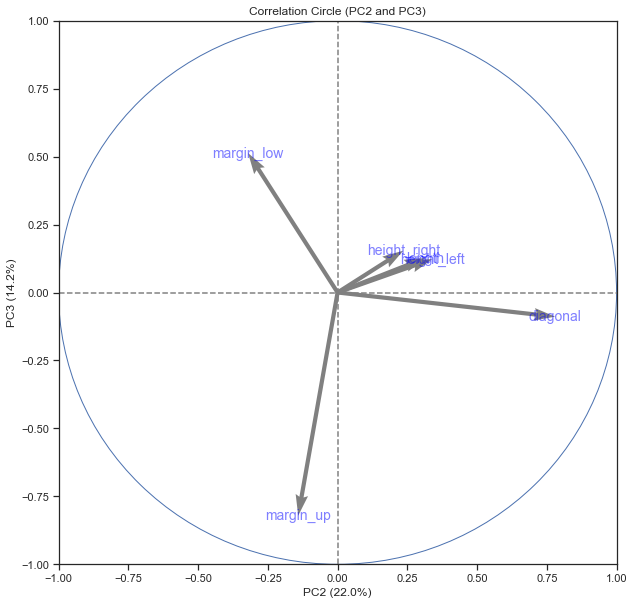

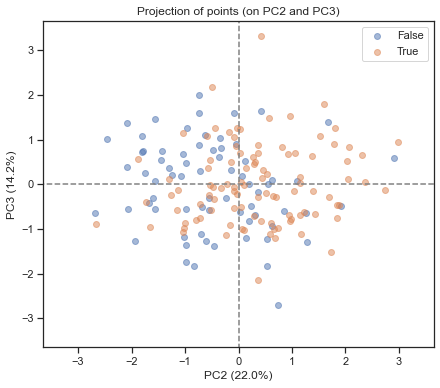

In [30]:
# Generate a correlation circle
pcs = pca.components_ 
display_circles(pcs, num_components, pca, [(1,2)], labels = np.array(X.columns),) 

# Transform the original scaled data to the new vector space and display data points
Vrai_Faux = [data.loc[uni_id, "is_genuine"] for uni_id in range(0,len(X_std))]
X_projected = pca.transform(X_std) 
display_factorial_planes(X_projected, num_components, pca, [(1,2)], illustrative_var = Vrai_Faux, alpha = 0.5)
 

> Nous pouvons voir que l'ACP a fait du bon travail.l'ACP a effectué ce travail avec une approche non supervisée. Elle ne savait rien des classements au préalable, mais elle a trouvé le plan optimal à travers les données, qui sépare très bien les faux et les vrais. 

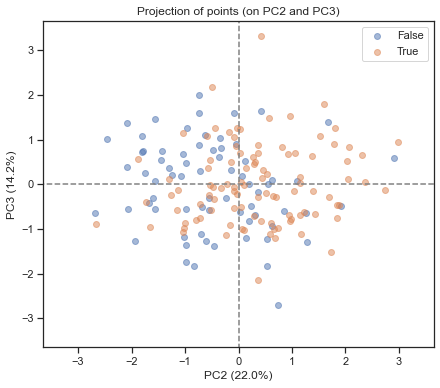

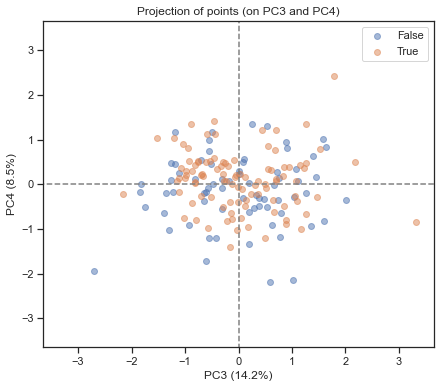

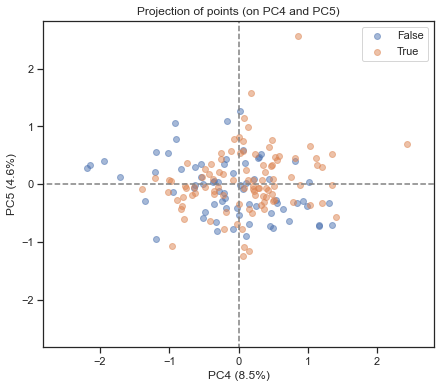

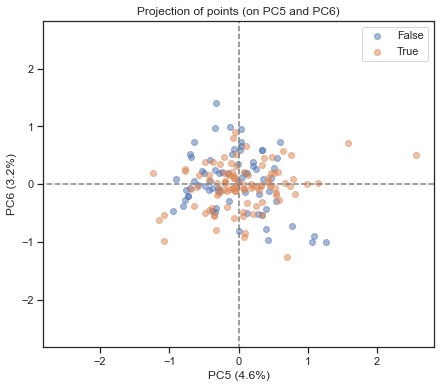

In [31]:
# Vérification de la qualité de séparation avec les autres plan factoriel 
display_factorial_planes(X_projected, num_components, pca, [(1,2),(2,3),(3,4),(4,5)], illustrative_var = Vrai_Faux, alpha = 0.5)
plt.show() 

> Projetés sur un plan à 2 dimensions (PC1 et PC2), les vrais et faux billets forment bien 2 groupes distincts, qu'on pourrait séparer par une ligne. 

> Nous procederons donc à une ACP à deux composantes. 

In [32]:
# ACP à deux composantes 
n_components = 2 
pca = PCA(n_components=n_components).fit(X_std)
print(
    'Variance expliquée :', 
    round(sum(pca.explained_variance_ratio_) * 100, 1), '%',
    '\nVariance par composante :', pca.explained_variance_ratio_)

Variance expliquée : 69.4 % 
Variance par composante : [0.47447921 0.21957106]


In [33]:
pca = PCA(n_components=n_components)
reduced = pca.fit_transform(X_std)

for i in range(0, n_components): 
    data['PC' + str(i + 1)] = reduced[:, i]

In [34]:
# To get the loadings, we just need to access the attribute components_ of the sklearn.decomposition.pca.PCA object.b
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=['diagonal','height_left','height_right','margin_low','margin_up','length'])
loadings


,PC1,PC2
diagonal,0.073275,0.779639
height_left,0.475502,0.339250
height_right,0.491821,0.235543
margin_low,0.431027,-0.320537
margin_up,0.352540,-0.141120
length,-0.465373,0.314536


> Les scores de corrélation montrent l'influence de chaque variable sur la composante principale et peuvent être représentés sur un cercle de corrélation.  

> l'ACP à deux composante PC1 et PC2 nous explique environs 70% de la variance. 

> La projection des observation sur le plan factoriel nous permet bien de distinguer les vrais et les faux billets. 

> Nous procederons sur une analyse du plan factoriel et du cercle des corrélation correspondant. 

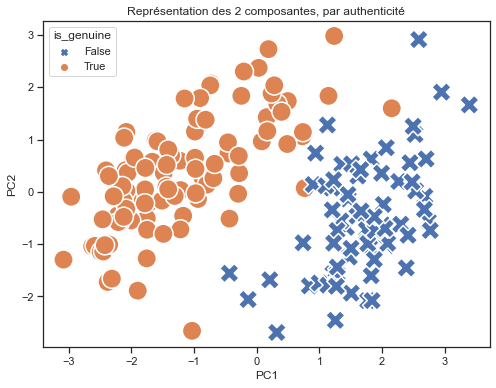

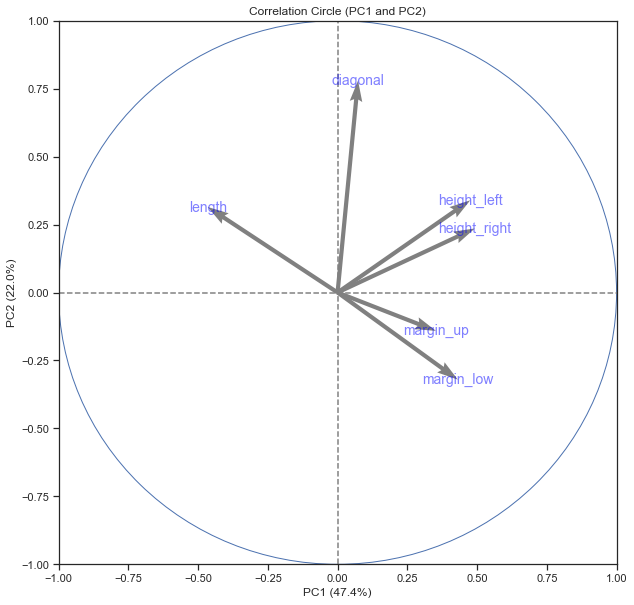

In [35]:
plt.figure(figsize=(8, 6))
scatter_markers = ['X','o']
sns.scatterplot(data=data, x='PC1', y='PC2', style='is_genuine', hue='is_genuine', markers=scatter_markers, s=375)
plt.title('Représentation des 2 composantes, par authenticité')
save_fig('acp_isgenuine')
plt.show() 

# Generate a correlation circle
pcs = pca.components_ 
display_circles(pcs, num_components, pca, [(0,1)], labels = np.array(X.columns),)  

####  Rappel sur  Plan factoriel, cercle des corrélations, et corrélation :  

On a un cercle de rayon 1. L'axe horizontal représente la composante principale 1. L'axe vertical représente la composante principale 2. À l'intérieur du cercle, nous avons des flèches qui pointent dans des directions particulières. Certaines de ces flèches sont plus longues que d'autres.

La longueur des flèches représente la mesure dans laquelle cette variable explique la variance des données sur le plan factoriel. On appelle parfois cela la qualité de la représentation de cette variable sur le plan.

L'angle entre les variables donne une indication du degré de corrélation entre les variables sur le plan factoriel.

Un petit angle indique que la représentation des deux variables sur le plan factoriel est positivement corrélée. 

Un angle de 90 degrés indique une absence de corrélation.  Ci-dessus, nous pouvons voir que l'international et le nombre d'étudiants sont peu corrélés sur ce plan factoriel.

Un angle de 180 degrés indique une corrélation négative.  


Notez qu'il est important de comprendre que l'angle entre les lignes ne vous donne pas une mesure de la corrélation entre les variables originales. Nous devons garder à l'esprit que les données ont été projetées sur ce plan factoriel. Ainsi, nous ne voyons réellement qu'une mesure de la corrélation sur le plan factoriel, et non dans les données d'origine. 


Si, toutefois, vous pensez voir des variables fortement corrélées (ou non corrélées) sur le cercle, calculez alors leurs coefficients de corrélation indépendamment pour vérifier. Sachez qu'il existe une représentation très pratique qui donne tous les coefficients de corrélation des variables deux à deux. Elle s'appelle la "matrice de corrélation".

 > Nous constatons que les variables "Height_left" et "Height_right" sont bien corrélées positivement avec l'axe PC1 tout comme "Margin_up" et "Margin_low"sont aussi corrélées positivement avec cet axe..

> La variable "Lenght" quant elle est négativement corrélées avec l'axe PC1 et la variable "Diagonal" a preque une abscence de corrélation ( proche de 90 degrés) avec PC1 mais positivement corrélées positivement avec PC2



# Clustering

> Le clustering est une méthode d'apprentissage non supervisée qui permet de trouver une structure sous-jacente dans un ensemble de points de données en regroupant les points de données en fonction de leur similarité. 

> K-means ne peut fonctionner qu'avec des données quantitatives, nous allons donc supprimer le is_genuine. Nous sommes intéressés par l'analyse des métriques sous-jacentes qui contribuent au score global.  

> K-means est une méthode de partitionnement où les points de données sont séparés en k clusters. Une fonction spécifique est utilisée pour déterminer la qualité des partitions. L'algorithme procède par amélioration itérative de la qualité de ces partitions. K-means fonctionne en sélectionnant d'abord un ensemble de points aléatoires. Nous les appelons centroïdes car ils seront les centres de nos groupes. L'algorithme k-means effectue donc plusieurs passages du processus  et choisit le résultat qui a la variance totale la plus faible. Le processus de détermination du centroïde le plus proche pour attribuer un point est simplement le calcul de la distance entre deux vecteurs, l'un étant le point de données et l'autre le centroïde. 

> De nouveau, nous appliquerons la fonction 'standard scaler' pour mettre à l'échelle nos données afin que toutes les variables aient une moyenne de 0 et un écart type de 1. (Ainsi, jusqu'à présent, nous avons traité les données exactement de la même manière que pour l'ACP).






In [36]:
from sklearn import cluster 
from sklearn.cluster import KMeans


In [37]:
# Create a k-means clustering model
kmeans = KMeans(init='random', n_clusters=6, n_init=10)

# Fit the data to the model
kmeans.fit(X_std)

# Determine which clusters each data point belongs to:
clusters =  kmeans.predict(X_std)

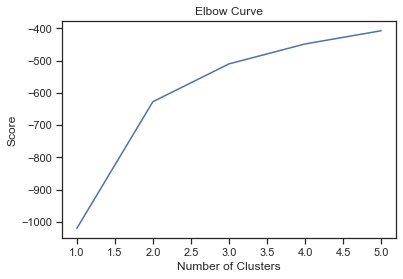

In [38]:
# Run a number of tests, for 1, 2, ... num_clusters
num_clusters = 6
kmeans_tests = [KMeans(n_clusters=i, init='random', n_init=10) for i in range(1, num_clusters)]
score = [kmeans_tests[i].fit(X_std).score(X_std) for i in range(len(kmeans_tests))]

# Plot the curve
plt.plot(range(1, num_clusters),score)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

> Nous utiserons la méthode Elbow qui effectue plusieurs tests avec différentes valeurs pour k (le nombre de clusters).  Pour chaque test, elle enregistre le score, qui est une mesure de la variance intra-groupe (en d'autres termes, le degré d'étanchéité des groupes) que nous pouvons ensuite tracer le score en fonction du nombre de clusters. 

> Au premier virage de la courbe nous l'identifions comme  le "coude" de la courbe. Vous pouvez voir que la courbe augmente fortement à partir de 1 jusqu'à environ 2 , mais commence à s'aplatir vers 3 groupes, la courbe est très plate et presque horizontale. Cela signifie qu'au-delà de 3 clusters environ, la réduction supplémentaire de la variance (ou l'augmentation du "resserrement" des clusters) diminue considérablement pour chaque cluster supplémentaire. Il n'y a donc guère d'intérêt à choisir plus de 2 clusters.  

> L'algorithme **K-means** va permettre de **vérifier si les données sont bien linéaires, séparables en 2 groupes distincts dans l'espace en 2 dimensions.** C'est à cette condition qu'on pourra s'appuyer sur une régression logistique pour classer les billets.

> On fixe le nombre de clusters à 2, étant donné qu'on cherchera par la régression logistique à déduire les 2 classes de *is_genuine*.

> D'autant plus que  que nous avons 6 dimensions, il est difficile de visualiser le résultat. 

In [39]:
# on fixe le nombre des cluster à 2.  
kmeans = sk.cluster.KMeans(n_clusters=2, random_state=0).fit(X)
[sk.cluster.KMeans(n_clusters=i, init='random', n_init=10) for i in range(1, num_clusters)]


#on ajoute la colonne cluster au dataframe. 
data['cluster'] = kmeans.predict(X)

# Inversion des 0 et des 1
dicto = {0: 1, 1: 0} 

# Pour que 0 soit égal à False
data['cluster'] = data['cluster'].map(dicto) 
data 


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,PC1,PC2,cluster
0,True,171.81,104.86,104.95,4.52,2.89,112.83,2.153639,1.599709,1
1,True,171.67,103.74,103.70,4.01,2.87,113.29,-2.110416,-0.526039,1
2,True,171.83,103.76,103.76,4.40,2.88,113.84,-1.973152,-0.048102,1
3,True,171.80,103.78,103.65,3.73,3.12,113.63,-2.059795,-0.089105,1
4,True,172.05,103.70,103.75,5.04,2.27,113.55,-2.403180,0.412170,1
...,...,...,...,...,...,...,...,...,...,...
165,False,172.11,104.23,104.45,5.24,3.58,111.78,2.478626,0.189974,0
166,False,173.01,104.59,104.31,5.04,3.05,110.91,2.585331,2.914472,0
167,False,172.47,104.27,104.10,4.88,3.33,110.68,2.067245,0.845602,0
168,False,171.82,103.97,103.88,4.73,3.55,111.87,0.739257,-0.972965,0


In [40]:
data_reduced= data[['is_genuine','PC1','PC2','cluster']]
data_reduced = data_reduced.set_index("is_genuine") 
data_reduced.head()

,PC1,PC2,cluster
is_genuine,,,
True,2.153639,1.599709,1
True,-2.110416,-0.526039,1
True,-1.973152,-0.048102,1
True,-2.059795,-0.089105,1
True,-2.403180,0.412170,1


In [41]:
from pandas.plotting import parallel_coordinates 

In [42]:
def addAlpha(colour, alpha):
    '''Add an alpha to the RGB colour'''
    
    return (colour[0],colour[1],colour[2],alpha)

def display_parallel_coordinates(df, num_clusters):
    '''Display a parallel coordinates plot for the clusters in df'''

    # Select data points for individual clusters
    cluster_points = []
    for i in range(num_clusters):
        cluster_points.append(df[df.cluster==i])
    
    # Create the plot
    fig = plt.figure(figsize=(12, 15))
    title = fig.suptitle("Parallel Coordinates Plot for the Clusters", fontsize=18)
    fig.subplots_adjust(top=0.95, wspace=0)

    # Display one plot for each cluster, with the lines for the main cluster appearing over the lines for the other clusters
    for i in range(num_clusters):    
        plt.subplot(num_clusters, 1, i+1)
        for j,c in enumerate(cluster_points): 
            if i!= j:
                pc = parallel_coordinates(c, 'cluster', color=[addAlpha(palette[j],0.2)])
        pc = parallel_coordinates(cluster_points[i], 'cluster', color=[addAlpha(palette[i],0.5)])

        # Stagger the axes
        ax=plt.gca()
        for tick in ax.xaxis.get_major_ticks()[1::2]:
            tick.set_pad(20)        


def display_parallel_coordinates_centroids(df, num_clusters):
    '''Display a parallel coordinates plot for the centroids in df'''

    # Create the plot
    fig = plt.figure(figsize=(12, 5))
    title = fig.suptitle("Parallel Coordinates plot for the Centroids", fontsize=18)
    fig.subplots_adjust(top=0.9, wspace=0)

    # Draw the chart
    parallel_coordinates(df, 'cluster', color=palette)

    # Stagger the axes
    ax=plt.gca()
    for tick in ax.xaxis.get_major_ticks()[1::2]:
        tick.set_pad(20) 

> Nous pouvons utiliser la technique du graphique à coordonnées parallèles pour voir comment les points de données individuels se situent parmi toutes nos variables. Dans le graphique suivant, chaque couleur représente un billet différent. En regardant comment les valeurs des variables se comparent à travers les clusters, nous pouvons avoir une idée de ce que les clusters représentent réellement. 

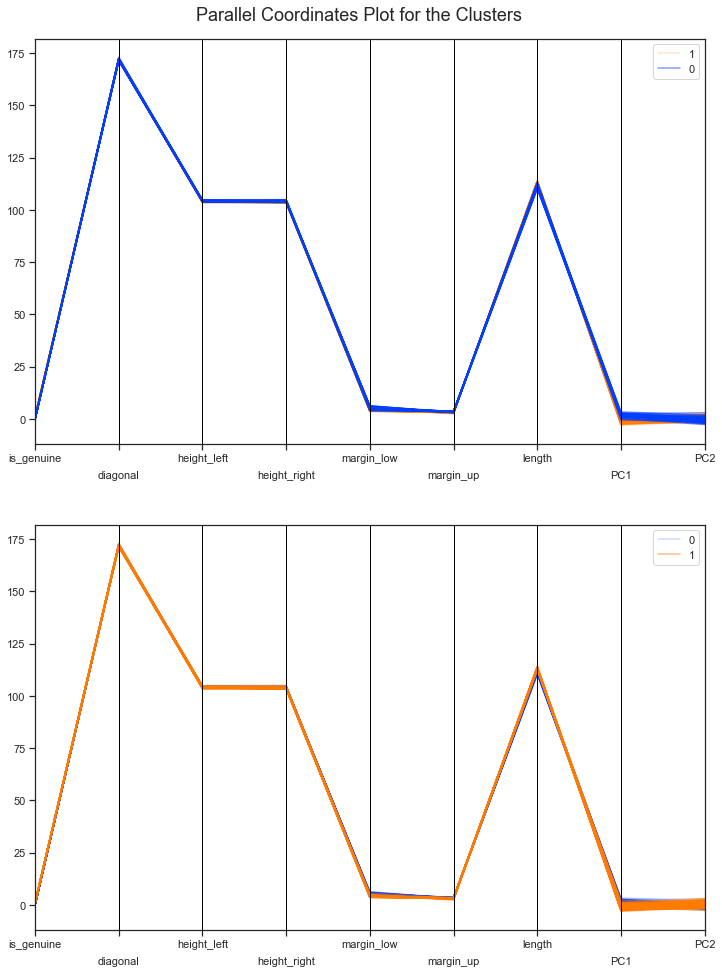

In [43]:
# Display parallel coordinates plots, one for each cluster
display_parallel_coordinates(data, 2) 

> Mais nous avons également une autre information utile qui ressort du clustering k-means : les centroïdes. Nous pouvons maintenant voir la variation entre les variables pour chacun des clusters trouvés par l'algorithme k-means. 


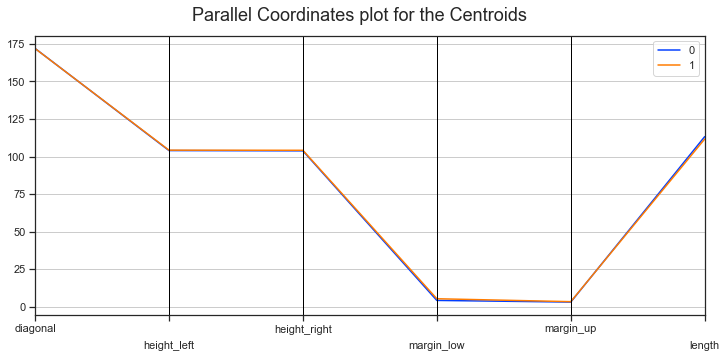

In [44]:
# Create a data frame containing our centroids
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
centroids['cluster'] = centroids.index 

display_parallel_coordinates_centroids(centroids, 2) 

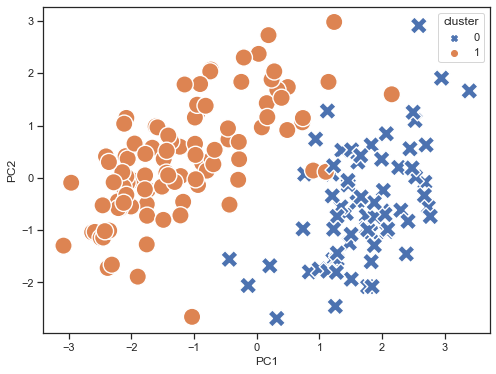

In [45]:
# affichage des cluster sur le plan factoriel avec PC1 et PC2. 
plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x='PC1', y='PC2', hue='cluster', style='cluster', markers=scatter_markers, s=300)
save_fig('kmeans-clusters')
plt.show() 

> Les clusters prédits correspondent à vue d'oeil aux vraies classes (*is_genuine*), et on peut comme attendu séparer les clusters par une ligne droite. Nos données sont donc adaptées pour une régression logistique.

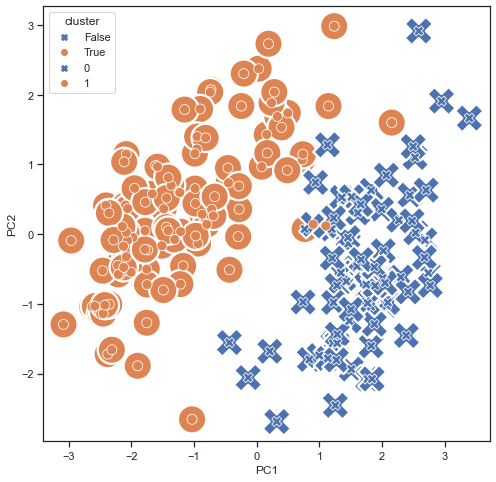

In [46]:
# Affichage des donnée réel sur les billet avec les données résultat du clustering
# Contour = classe réelle ; Point = cluster
plt.figure(figsize=(8,8))
sns.scatterplot(data=data, x='PC1', y='PC2', markers=scatter_markers, style='is_genuine', hue='is_genuine', s=800)
sns.scatterplot(data=data, x='PC1', y='PC2', markers=scatter_markers, style='cluster', hue='cluster', s=100)
save_fig('kmeans_comparaison') 
plt.show() 

> Si on projette sur le même plan la vraie classe (*is_genuine*) et la classe prédite (*cluster*), seuls 3 billets apparaîssent mal classés (les plus gros points indiquent la classe réelle, les petits le cluster).

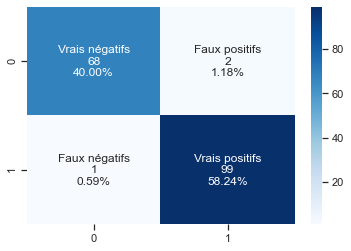

              precision    recall  f1-score   support

       False       0.99      0.97      0.98        70
        True       0.98      0.99      0.99       100

    accuracy                           0.98       170
   macro avg       0.98      0.98      0.98       170
weighted avg       0.98      0.98      0.98       170



In [47]:
def matrice_confusion(a, b, nom_graphique):
    confusion_matrix = sk.metrics.confusion_matrix(a,b)
    group_names = ['Vrais négatifs','Faux positifs','Faux négatifs','Vrais positifs']
    group_counts = ['{0:0.0f}'.format(value) for value in confusion_matrix.flatten()]
    group_percentages = [
        '{0:.2%}'.format(value) for value in confusion_matrix.flatten()/np.sum(confusion_matrix)]
    labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in
              zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(confusion_matrix, annot=labels, fmt='', cmap='Blues')
    save_fig(nom_graphique)
    plt.show()
    
    classification = sk.metrics.classification_report(a,b)
    print(classification)
    
matrice_confusion(data['is_genuine'], data['cluster'], 'kmeans_matrice-confusion')

On vérifie le nombre d'individus vrais détectés faux 
avec une **matrice de confusion**.

|                      | Prédit : faux  | Prédit : vrai  |
| -------------------- |:-------------: | -------------: |
| Valeur réelle : faux | Vrais négatifs | Faux positifs  |
| Valeur réelle : vrai | Faux négatifs  | Vrais positifs |

> Deux faux billets ont été considérés comme vrais par le clustering, et seul un vrai billet a été détecté comme faux.

# Régression logistic : 

In [48]:
data.head() 

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,PC1,PC2,cluster
0,True,171.81,104.86,104.95,4.52,2.89,112.83,2.153639,1.599709,1
1,True,171.67,103.74,103.70,4.01,2.87,113.29,-2.110416,-0.526039,1
2,True,171.83,103.76,103.76,4.40,2.88,113.84,-1.973152,-0.048102,1
3,True,171.80,103.78,103.65,3.73,3.12,113.63,-2.059795,-0.089105,1
4,True,172.05,103.70,103.75,5.04,2.27,113.55,-2.403180,0.412170,1


In [49]:
data.is_genuine.dtypes

dtype('bool')

> Pour le traitement, nous allons transformer la variable is_genuine pour :

> True = 1

> False = 0


In [50]:
data['is_genuine'] = data['is_genuine'].apply(lambda x: 0 if x == False else 1)
data["is_genuine"] = data["is_genuine"].astype('category') 
data.head() 

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,PC1,PC2,cluster
0,1,171.81,104.86,104.95,4.52,2.89,112.83,2.153639,1.599709,1
1,1,171.67,103.74,103.70,4.01,2.87,113.29,-2.110416,-0.526039,1
2,1,171.83,103.76,103.76,4.40,2.88,113.84,-1.973152,-0.048102,1
3,1,171.80,103.78,103.65,3.73,3.12,113.63,-2.059795,-0.089105,1
4,1,172.05,103.70,103.75,5.04,2.27,113.55,-2.403180,0.412170,1


# Modélisation

## Split

On dissocie *is_genuine* (qu'on appelle `y` : la target) des autres variables standardisées (`X`). 

> Nous allons ensuite subdiviser notre jeu de données pour obtenir un échantillon de test et un echantillon d'entrainement. 

In [51]:
#data['is_genuine'] = pd.to_numeric(data['is_genuine'])
y = data['is_genuine'] # Target
y.head() 

0    1
1    1
2    1
3    1
4    1
Name: is_genuine, dtype: category
Categories (2, int64): [0, 1]

In [52]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(
    X_std, y, test_size=0.33, random_state=42)

print('X_train :', len(X_train), 'lignes',
    '\ny_train :', len(y_train), 'lignes',
    '\nX_test :', len(X_test), 'lignes', 
    '\ny_test :', len(y_test), 'lignes')  

X_train : 113 lignes 
y_train : 113 lignes 
X_test : 57 lignes 
y_test : 57 lignes


`X` et `y` sont divisés en 2 échantillons `train` et `test`. Les jeux test représenteront ici un tiers des données.

In [53]:
X_train.head()  

,diagonal,height_left,height_right,margin_low,margin_up,length
27,0.260479,0.550431,1.005688,0.439810,-1.189874,0.997682
78,0.719695,1.088596,-0.236716,-1.202966,0.634749,-0.022145
147,1.014905,1.525854,0.884478,0.054115,1.101513,-2.267934
38,0.883700,0.684972,0.248124,-0.545855,-1.614205,1.312309
41,-0.428344,0.113173,-0.721557,-0.460145,-0.935275,0.162292


In [54]:
X_train.info() 

<class 'pandas.core.frame.DataFrame'>
Int64Index: 113 entries, 27 to 102
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   diagonal      113 non-null    float64
 1   height_left   113 non-null    float64
 2   height_right  113 non-null    float64
 3   margin_low    113 non-null    float64
 4   margin_up     113 non-null    float64
 5   length        113 non-null    float64
dtypes: float64(6)
memory usage: 6.2 KB


In [55]:
X_train.apply(lambda s: pd.to_numeric(s, errors='coerce').notnull().all())

diagonal        True
height_left     True
height_right    True
margin_low      True
margin_up       True
length          True
dtype: bool

In [56]:
y_train

27     1
78     1
147    0
38     1
41     1
      ..
71     1
106    0
14     1
92     1
102    0
Name: is_genuine, Length: 113, dtype: category
Categories (2, int64): [0, 1]

#### Synthèse des oprérations et manipulation effectuée : 

In [57]:
import statsmodels.api as sm

regression = sk.linear_model.LogisticRegression()
regression.fit(X_train, y_train)

max_iter = 300
res_sm = sm.Logit(y_train, X_train).fit(method = "ncg", maxiter = max_iter)
res_sm.summary() 

Optimization terminated successfully.
         Current function value: 0.000019
         Iterations: 13
         Function evaluations: 13
         Gradient evaluations: 13
         Hessian evaluations: 13


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             is_genuine   No. Observations:                  113
Model:                          Logit   Df Residuals:                      107
Method:                           MLE   Df Model:                            5
Date:                Wed, 15 Dec 2021   Pseudo R-squ.:                   1.000
Time:                        11:22:48   Log-Likelihood:             -0.0021806
converged:                       True   LL-Null:                       -77.042
Covariance Type:            nonrobust   LLR p-value:                 1.807e-31
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
diagonal        -0.3806     21.673     -0.018      0.986     -42.858      42.097
height_left      1.9895     75.986      0.026      0.979    -146.940     150.919
height_right    -3.6118     80.706     -0.045      0.964    -161.793     154.570
margin_low     -16.9883     62.881     -0.270      0.787    -140.233     106.256
margin_up       -7.6488     54.970     -0.139      0.889    -115.388     100.091
length          13.8558    105.726      0.131      0.896    -193.364     221.076
================================================================================

Possibly complete quasi-separation: A fraction 0.96 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

>  Statsmodels décide par défaut qu’il n’y a pas de constante, il faudrait donc ajouter une colonne dans les données pour la constante car tout nos prédicteurs sont continus. Cependant, les valeurs contenues dans x sont théoriquement toujours dans une fourchette précise (il s'agit des côtes des billets) et ne pourront jamais être égale à 0. Nous n'allons donc pas ajouter de constante dans ce cas précis.

> Nous allons à présent effectuer les prédictions sur la base de test.

In [58]:
# Tester le modèle 
pd.DataFrame(
    regression.predict_proba(X_test)).rename(
    columns={0: 'False', 1: 'True'}).head(10)

,False,True
0,0.891750,0.108250
1,0.008633,0.991367
2,0.996318,0.003682
3,0.000202,0.999798
4,0.495264,0.504736
5,0.997718,0.002282
6,0.963555,0.036445
7,0.063299,0.936701
8,0.960113,0.039887
9,0.004716,0.995284


> > En sortie, on obtient pour chaque billet la probabilité qu'il soit vrai, et celle qu'il soit faux.

In [59]:
# Prédictions sur l'échantillon-test
y_log = regression.predict(X_test) 

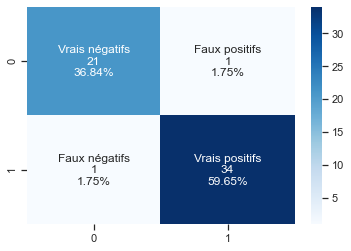

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        22
           1       0.97      0.97      0.97        35

    accuracy                           0.96        57
   macro avg       0.96      0.96      0.96        57
weighted avg       0.96      0.96      0.96        57



In [60]:
matrice_confusion(y_test, y_log, 'reg_matrice-confusion')  

> En comparant la target réelle du jeu test et nos prédictions, on constate qu'un seul faux billet a été prédit comme vrai, et un vrai billet a été considéré faux.

# Programme de détection

Pour détecter l'authenticité des billets, le programme acceptera un fichier CSV sur ce modèle :

In [61]:
billets = pd.read_csv('/Users/tahirihoussain/Desktop/_AAAAOPENCLASSROOMS/PROJET 6 /detection-faux-billets v2/example.csv') # nom de fichier qui va etre envoyer le jour de la soutenance
X_csv = billets.drop(['id'], axis=1)    
X_csv = pd.DataFrame(std_scale.transform(X_csv), columns=X_csv.columns) # CSV standardisé

y_log = regression.predict(X_csv) # Prédictions
predictions = []
for i in range(0, len(y_log)):
    predictions.append(y_log[i])
    
predictions = pd.concat([ # Jointure des prédictions
    pd.DataFrame(
    [predictions]).rename(index={0: 'Prédiction'}).T.replace(
    {False: 'Faux billet', True: 'Vrai billet'}),
    pd.DataFrame(
    regression.predict_proba(X_csv)).rename(
    columns={0: 'Probabilité de faux', 1: 'Probabilité de vrai'})], axis=1)
predictions['id'] = billets['id'].unique()

predictions 

,Prédiction,Probabilité de faux,Probabilité de vrai,id
0,Faux billet,0.962899,0.037101,A_1
1,Faux billet,0.994102,0.005898,A_2
2,Faux billet,0.986890,0.013110,A_3
3,Vrai billet,0.058722,0.941278,A_4
4,Vrai billet,0.004059,0.995941,A_5
